# ASSIGNMENT 03 - NEURAL NETWORKS AND REPRESENTATION LEARNING
## Hệ thống 2 - Dự đoán giá nhà

**Dataset:** Poland OLX House Price Q1 2022  
**Target:** `price`  
**Problem:** Regression

**Mục tiêu**
- 3 mô hình Machine Learning cơ bản.
- Baseline MLP, Deeper MLP và Deep Learning 5 Linear Layers.
- So sánh learning rate `0.001` và `0.01`.
- MAE, MSE, RMSE và R².
- Learned Representation bằng PCA.

In [1]:
import os, copy, random, joblib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.14.0+cpu
Device: cpu


In [2]:
# 1. Đọc và kiểm tra dữ liệu
DATA_PATH = Path("Data/house.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Không tìm thấy Data/house.csv")

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", int(df.duplicated().sum()))

df.head()

Shape: (62818, 16)
Columns: ['offer_title', 'price', 'price_per_meter', 'offer_type', 'floor', 'area', 'rooms', 'offer_type_of_building', 'market', 'city_name', 'voivodeship', 'month', 'year', 'population', 'longitude', 'latitude']

Missing values:
offer_title                  0
price                        0
price_per_meter              0
offer_type                   0
floor                     1487
area                      1487
rooms                        0
offer_type_of_building    1487
market                       0
city_name                    0
voivodeship                  0
month                        0
year                         0
population                   0
longitude                    0
latitude                     0
dtype: int64

Duplicate rows: 10482


,offer_title,price,price_per_meter,offer_type,floor,area,rooms,offer_type_of_building,market,city_name,voivodeship,month,year,population,longitude,latitude
0,Kawalerka na sprzedaĹĽ,240000.0,8888.89,Private,1.0,27.00,1,Housing Block,primary,BolesĹ‚awiec,Lower Silesia,January,2022,39603,15.565105,51.263033
1,Nowoczesna kawalerka z winda plus garaĹĽ podzi...,250000.0,7142.86,Private,1.0,35.00,1,Housing Block,primary,Jelcz-Laskowice,Lower Silesia,January,2022,15828,17.349964,51.039831
2,Nowa kawalerka z Balkonem/Legnicka/Magnolia,259000.0,10360.00,Estate Agency,2.0,25.00,1,Housing Block,primary,WrocĹ‚aw,Lower Silesia,January,2022,634487,17.032669,51.108978
3,Kawalerka z balkonem/klucze I kwartaĹ‚ 2022/60...,269000.0,10275.02,Private,3.0,26.18,1,Apartment Building,primary,WrocĹ‚aw,Lower Silesia,January,2022,634487,17.032669,51.108978
4,40 tys. taniej od dewelopera/Kawalerka/Magnoli...,258000.0,9923.08,Estate Agency,3.0,26.00,1,Housing Block,primary,WrocĹ‚aw,Lower Silesia,January,2022,634487,17.032669,51.108978


Clean rows: 52146
Price range: 10000.0 - 6000000.0
Area range: 11.0 - 450.0


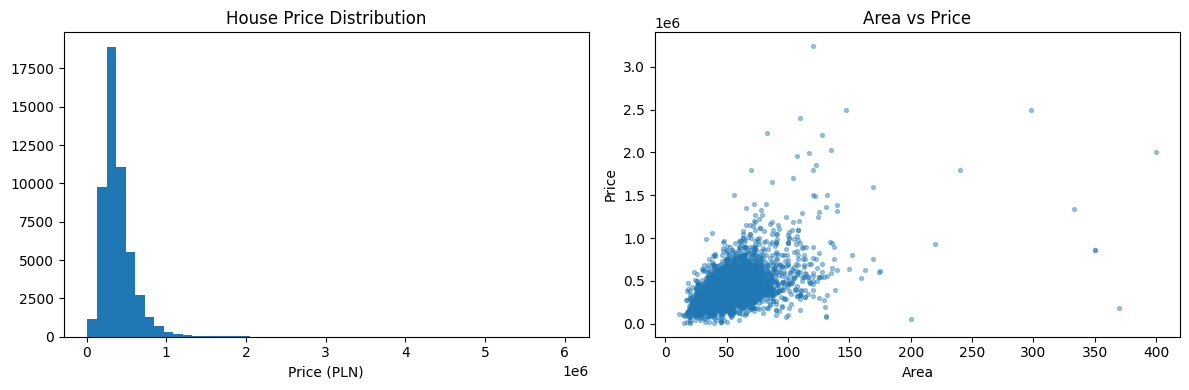

In [3]:
# 2. Cleaning + EDA cơ bản
df_clean = df.copy().drop_duplicates()

for col in [
    "price", "area", "price_per_meter",
    "floor", "rooms", "population", "longitude", "latitude"
]:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

df_clean = df_clean.dropna(subset=["price"])
df_clean = df_clean[df_clean["price"].between(10_000, 10_000_000)]
df_clean = df_clean[
    df_clean["area"].isna()
    |
    df_clean["area"].between(
        10,
        500
    )
]

if "price_per_meter" in df_clean.columns:
    df_clean = df_clean[
        df_clean["price_per_meter"].isna()
        | (df_clean["price_per_meter"] <= 100_000)
    ]

df_clean = df_clean.reset_index(drop=True)

print("Clean rows:", len(df_clean))
print("Price range:", df_clean["price"].min(), "-", df_clean["price"].max())
print("Area range:", df_clean["area"].min(), "-", df_clean["area"].max())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(df_clean["price"], bins=50)
ax[0].set_title("House Price Distribution")
ax[0].set_xlabel("Price (PLN)")

sample = df_clean.sample(min(5000, len(df_clean)), random_state=SEED)
ax[1].scatter(sample["area"], sample["price"], s=8, alpha=0.4)
ax[1].set_title("Area vs Price")
ax[1].set_xlabel("Area")
ax[1].set_ylabel("Price")

plt.tight_layout()
plt.show()

In [4]:
# 3. X/y và chia 70/15/15
TARGET = "price"

NUM_FEATURES = [
    "floor", "area", "rooms",
    "population", "longitude", "latitude"
]

CAT_FEATURES = [
    "offer_type", "offer_type_of_building",
    "market", "city_name", "voivodeship", "month"
]

required = [TARGET] + NUM_FEATURES + CAT_FEATURES
missing = [c for c in required if c not in df_clean.columns]
if missing:
    raise ValueError(f"Thiếu các cột: {missing}")

X = df_clean[NUM_FEATURES + CAT_FEATURES].copy()
y = df_clean[TARGET].astype(float)

for col in CAT_FEATURES:
    X[col] = X[col].astype("object")

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (36502, 12)
Validation: (7822, 12)
Test: (7822, 12)


In [5]:
# 4. Preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, NUM_FEATURES),
        ("cat", categorical_pipeline, CAT_FEATURES)
    ],
    sparse_threshold=1.0
)

X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

print("Raw train:", X_train.shape)
print("Encoded train:", X_train_t.shape)
print("Encoded dimension:", X_train_t.shape[1])

Raw train: (36502, 12)
Encoded train: (36502, 633)
Encoded dimension: 633


In [6]:
# 5. Ba mô hình Machine Learning cơ bản
def reg_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

linear_model = LinearRegression()
ridge_model = Ridge(alpha=1.0, solver="lsqr")
rf_model = RandomForestRegressor(
    n_estimators=80, max_depth=20, min_samples_leaf=2,
    random_state=SEED, n_jobs=-1
)

linear_model.fit(X_train_t, y_train)
ridge_model.fit(X_train_t, y_train)
rf_model.fit(X_train_t, y_train)

ml_predictions = {
    "Linear Regression": linear_model.predict(X_test_t),
    "Ridge Regression": ridge_model.predict(X_test_t),
    "Random Forest": rf_model.predict(X_test_t)
}

ml_results = pd.DataFrame([
    {"Model": name, **reg_metrics(y_test, pred)}
    for name, pred in ml_predictions.items()
])

ml_results.round(2)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,71870.72,1.708996e+10,130728.57,0.64
1,Ridge Regression,71833.49,1.707879e+10,130685.84,0.64
2,Random Forest,54428.07,1.072254e+10,103549.71,0.77


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,71870.72,1.708996e+10,130728.57,0.64
1,Ridge Regression,71833.49,1.707879e+10,130685.84,0.64
2,Random Forest,54428.07,1.072254e+10,103549.71,0.77


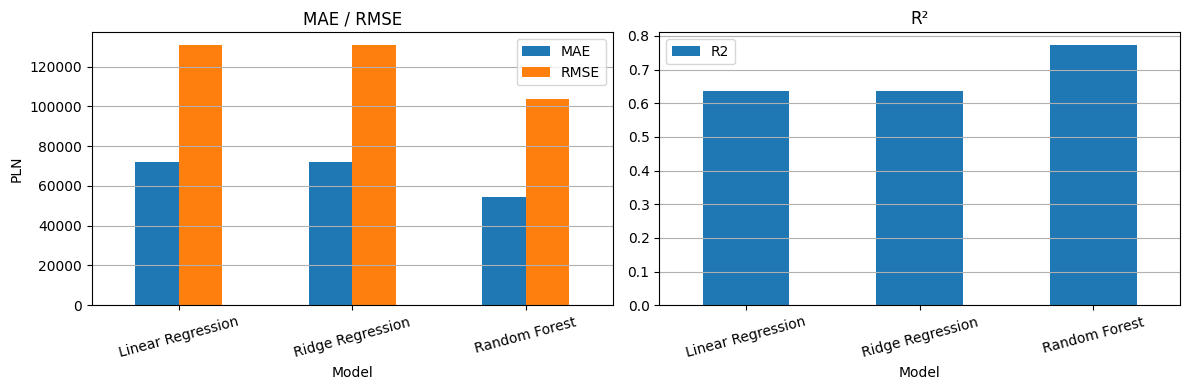

In [7]:
# 6. So sánh 3 ML models
display(ml_results.round(2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ml_results.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar", ax=ax[0])
ax[0].set_title("MAE / RMSE")
ax[0].set_ylabel("PLN")
ax[0].tick_params(axis="x", rotation=15)
ax[0].grid(axis="y")

ml_results.set_index("Model")[["R2"]].plot(kind="bar", ax=ax[1])
ax[1].set_title("R²")
ax[1].tick_params(axis="x", rotation=15)
ax[1].grid(axis="y")

plt.tight_layout()
plt.show()

In [8]:
# 7. Chuẩn bị dữ liệu cho PyTorch
def to_dense_float32(matrix):
    if hasattr(matrix, "toarray"):
        return matrix.toarray().astype(np.float32)
    return np.asarray(matrix, dtype=np.float32)

X_train_dense = to_dense_float32(X_train_t)
X_val_dense = to_dense_float32(X_val_t)
X_test_dense = to_dense_float32(X_test_t)

target_scaler = StandardScaler()

y_train_scaled = target_scaler.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).ravel().astype(np.float32)

y_val_scaled = target_scaler.transform(
    y_val.to_numpy().reshape(-1, 1)
).ravel().astype(np.float32)

y_test_scaled = target_scaler.transform(
    y_test.to_numpy().reshape(-1, 1)
).ravel().astype(np.float32)

X_train_tensor = torch.tensor(X_train_dense, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_dense, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_dense, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

BATCH_SIZE = 256

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def make_train_loader(seed=SEED):
    g = torch.Generator()
    g.manual_seed(seed)
    return DataLoader(
        train_dataset, batch_size=BATCH_SIZE,
        shuffle=True, generator=g
    )

print("Tensor train:", X_train_tensor.shape)

Tensor train: torch.Size([36502, 633])


In [9]:
# 8. Các kiến trúc Neural Network
INPUT_DIM = X_train_dense.shape[1]

class BaselineMLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

class DeeperMLP(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

class DeepMLP5(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.fc1 = nn.Linear(d, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 8)
        self.fc5 = nn.Linear(8, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(h1))
        h3 = self.relu(self.fc3(h2))
        h4 = self.relu(self.fc4(h3))
        return self.fc5(h4).squeeze(1)

    def extract_features(self, x):
        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(h1))
        h3 = self.relu(self.fc3(h2))
        h4 = self.relu(self.fc4(h3))
        return h1, h2, h3, h4

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

for m in [BaselineMLP(INPUT_DIM), DeeperMLP(INPUT_DIM), DeepMLP5(INPUT_DIM)]:
    print(m.__class__.__name__, "-", count_parameters(m), "parameters")

BaselineMLP - 40641 parameters
DeeperMLP - 42689 parameters
DeepMLP5 - 43329 parameters


In [10]:
# 9. Hàm train/evaluate dùng chung
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = total = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total += xb.size(0)

    avg_loss = total_loss / total
    rmse_pln = np.sqrt(avg_loss) * target_scaler.scale_[0]
    return avg_loss, rmse_pln

def evaluate_dl(model, loader, criterion):
    model.eval()
    total_loss = total = 0
    pred_scaled, target_scaled = [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)

            total_loss += loss.item() * xb.size(0)
            total += xb.size(0)
            pred_scaled.extend(pred.cpu().numpy())
            target_scaled.extend(yb.cpu().numpy())

    pred_scaled = np.asarray(pred_scaled)
    target_scaled = np.asarray(target_scaled)

    pred_original = target_scaler.inverse_transform(
        pred_scaled.reshape(-1, 1)
    ).ravel()

    target_original = target_scaler.inverse_transform(
        target_scaled.reshape(-1, 1)
    ).ravel()

    metrics = reg_metrics(target_original, pred_original)
    metrics["Loss"] = total_loss / total
    return metrics, pred_original, target_original

def train_model(model, lr, epochs=20, seed=SEED):
    torch.manual_seed(seed)
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loader = make_train_loader(seed)

    history = {
        "train_loss": [], "val_loss": [],
        "train_rmse": [], "val_rmse": []
    }

    best_rmse, best_state, best_epoch = np.inf, None, 0

    for epoch in range(epochs):
        train_loss, train_rmse = train_one_epoch(
            model, loader, criterion, optimizer
        )

        val_metrics, _, _ = evaluate_dl(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["Loss"])
        history["train_rmse"].append(train_rmse)
        history["val_rmse"].append(val_metrics["RMSE"])

        if val_metrics["RMSE"] < best_rmse:
            best_rmse = val_metrics["RMSE"]
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 5 == 0:
            print(
                f"Epoch {epoch+1:02d}/{epochs} | "
                f"Train RMSE {train_rmse:,.0f} | "
                f"Val RMSE {val_metrics['RMSE']:,.0f}"
            )

    model.load_state_dict(best_state)
    return model, history, best_epoch, best_rmse

def plot_history(history, title):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    ax[0].plot(history["train_loss"], label="Train")
    ax[0].plot(history["val_loss"], label="Validation")
    ax[0].set_title(f"{title} - Loss")
    ax[0].legend()
    ax[0].grid()

    ax[1].plot(history["train_rmse"], label="Train")
    ax[1].plot(history["val_rmse"], label="Validation")
    ax[1].set_title(f"{title} - RMSE")
    ax[1].set_ylabel("PLN")
    ax[1].legend()
    ax[1].grid()

    plt.tight_layout()
    plt.show()

## 10. Cấu hình thí nghiệm Neural Network

- Batch size: **256**
- Epochs: **20**
- Loss: **MSELoss**
- Optimizer: **Adam**
- Activation: **ReLU**
- Model selection: **Validation RMSE**

Experiments:
1. Baseline: `d → 64 → 1`
2. Deeper: `d → 64 → 32 → 1`
3. 5-Layer: `d → 64 → 32 → 16 → 8 → 1`, so sánh LR `0.001` và `0.01`.

In [11]:
# 11. Experiment 1 - Baseline
baseline_model, baseline_history, baseline_epoch, baseline_val_rmse = train_model(
    BaselineMLP(INPUT_DIM), lr=0.001
)

print("Best epoch:", baseline_epoch)
print("Best validation RMSE:", f"{baseline_val_rmse:,.2f} PLN")

Epoch 05/20 | Train RMSE 121,104 | Val RMSE 114,972
Epoch 10/20 | Train RMSE 115,410 | Val RMSE 110,404
Epoch 15/20 | Train RMSE 112,242 | Val RMSE 109,874
Epoch 20/20 | Train RMSE 109,950 | Val RMSE 111,034
Best epoch: 19
Best validation RMSE: 108,116.74 PLN


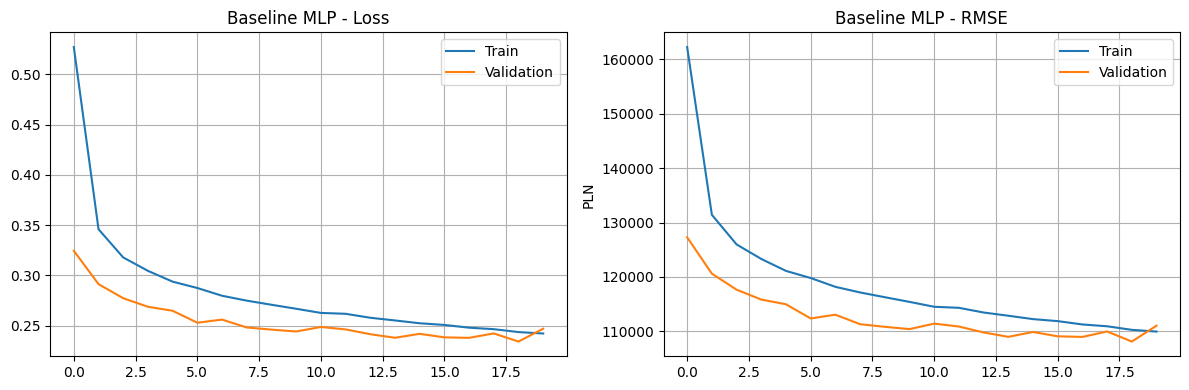

In [12]:
plot_history(baseline_history, "Baseline MLP")

In [13]:
# 12. Experiment 2 - Deeper
deeper_model, deeper_history, deeper_epoch, deeper_val_rmse = train_model(
    DeeperMLP(INPUT_DIM), lr=0.001
)

print("Best epoch:", deeper_epoch)
print("Best validation RMSE:", f"{deeper_val_rmse:,.2f} PLN")

Epoch 05/20 | Train RMSE 116,979 | Val RMSE 110,194
Epoch 10/20 | Train RMSE 110,423 | Val RMSE 106,678
Epoch 15/20 | Train RMSE 106,041 | Val RMSE 106,941
Epoch 20/20 | Train RMSE 102,754 | Val RMSE 110,378
Best epoch: 19
Best validation RMSE: 106,377.36 PLN


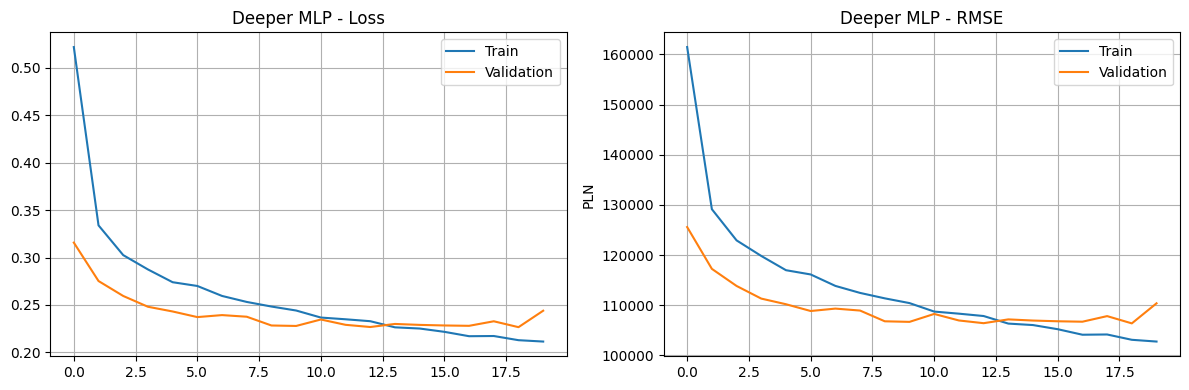

In [14]:
plot_history(deeper_history, "Deeper MLP")

In [15]:
# 13. Experiment 3 - 5 Layers, hai learning rate
deep5_lr001, hist_lr001, epoch_lr001, val_rmse_lr001 = train_model(
    DeepMLP5(INPUT_DIM), lr=0.001
)

deep5_lr01, hist_lr01, epoch_lr01, val_rmse_lr01 = train_model(
    DeepMLP5(INPUT_DIM), lr=0.01
)

print("LR 0.001 ->", f"{val_rmse_lr001:,.2f} PLN")
print("LR 0.01  ->", f"{val_rmse_lr01:,.2f} PLN")

if val_rmse_lr001 <= val_rmse_lr01:
    final_dl_model, final_dl_lr = deep5_lr001, 0.001
else:
    final_dl_model, final_dl_lr = deep5_lr01, 0.01

Epoch 05/20 | Train RMSE 117,614 | Val RMSE 109,773
Epoch 10/20 | Train RMSE 111,393 | Val RMSE 107,132
Epoch 15/20 | Train RMSE 107,043 | Val RMSE 107,845
Epoch 20/20 | Train RMSE 103,289 | Val RMSE 113,089
Epoch 05/20 | Train RMSE 111,307 | Val RMSE 114,438
Epoch 10/20 | Train RMSE 102,810 | Val RMSE 111,034
Epoch 15/20 | Train RMSE 96,712 | Val RMSE 111,003
Epoch 20/20 | Train RMSE 92,649 | Val RMSE 117,174
LR 0.001 -> 106,586.51 PLN
LR 0.01  -> 104,293.94 PLN


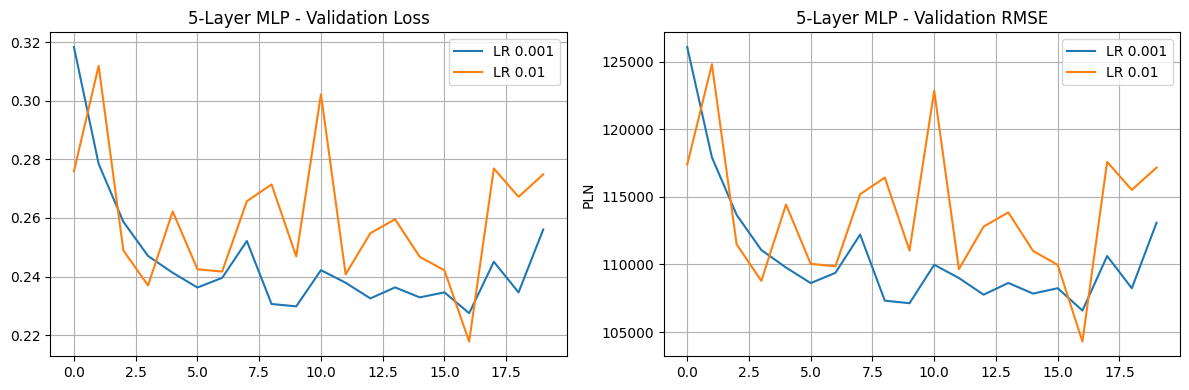

In [16]:
# 14. So sánh learning rate
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(hist_lr001["val_loss"], label="LR 0.001")
ax[0].plot(hist_lr01["val_loss"], label="LR 0.01")
ax[0].set_title("5-Layer MLP - Validation Loss")
ax[0].legend()
ax[0].grid()

ax[1].plot(hist_lr001["val_rmse"], label="LR 0.001")
ax[1].plot(hist_lr01["val_rmse"], label="LR 0.01")
ax[1].set_title("5-Layer MLP - Validation RMSE")
ax[1].set_ylabel("PLN")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.show()

In [17]:
# 15. Đánh giá Neural Network trên Test
criterion_test = nn.MSELoss()

dl_models = [
    ("Baseline MLP", baseline_model, f"{INPUT_DIM}-64-1", 0.001, baseline_epoch),
    ("Deeper MLP", deeper_model, f"{INPUT_DIM}-64-32-1", 0.001, deeper_epoch),
    ("5-Layer MLP (0.001)", deep5_lr001, f"{INPUT_DIM}-64-32-16-8-1", 0.001, epoch_lr001),
    ("5-Layer MLP (0.01)", deep5_lr01, f"{INPUT_DIM}-64-32-16-8-1", 0.01, epoch_lr01),
]

dl_rows = []
dl_predictions = {}

for name, model, arch, lr, epoch in dl_models:
    metrics, pred, target_true = evaluate_dl(model, test_loader, criterion_test)
    dl_predictions[name] = pred
    dl_rows.append({
        "Model": name,
        "Architecture": arch,
        "Parameters": count_parameters(model),
        "Learning Rate": lr,
        "Best Epoch": epoch,
        **metrics
    })

dl_results = pd.DataFrame(dl_rows)
dl_results.round(2)

,Model,Architecture,Parameters,Learning Rate,Best Epoch,MAE,MSE,RMSE,R2,Loss
0,Baseline MLP,633-64-1,40641,0.00,19,62120.62,1.254487e+10,112003.87,0.73,0.25
1,Deeper MLP,633-64-32-1,42689,0.00,19,61330.41,1.186787e+10,108939.74,0.75,0.24
2,5-Layer MLP (0.001),633-64-32-16-8-1,43329,0.00,17,60611.22,1.222587e+10,110570.64,0.74,0.24
3,5-Layer MLP (0.01),633-64-32-16-8-1,43329,0.01,17,58240.36,1.104670e+10,105103.26,0.77,0.22


,Model,MAE,MSE,RMSE,R2
2,Random Forest,54428.07,1.072254e+10,103549.71,0.77
6,5-Layer MLP (0.01),58240.36,1.104670e+10,105103.26,0.77
4,Deeper MLP,61330.41,1.186787e+10,108939.74,0.75
5,5-Layer MLP (0.001),60611.22,1.222587e+10,110570.64,0.74
3,Baseline MLP,62120.62,1.254487e+10,112003.87,0.73
1,Ridge Regression,71833.49,1.707879e+10,130685.84,0.64
0,Linear Regression,71870.72,1.708996e+10,130728.57,0.64


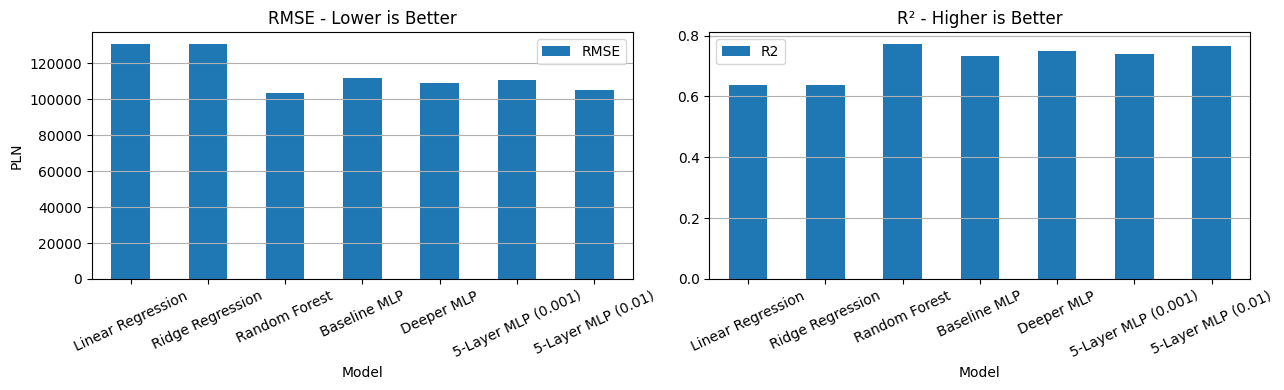

In [18]:
# 16. Tổng hợp ML và DL
all_results = pd.concat(
    [
        ml_results,
        dl_results[["Model", "MAE", "MSE", "RMSE", "R2"]]
    ],
    ignore_index=True
)

display(all_results.sort_values("RMSE").round(2))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

all_results.set_index("Model")[["RMSE"]].plot(kind="bar", ax=ax[0])
ax[0].set_title("RMSE - Lower is Better")
ax[0].set_ylabel("PLN")
ax[0].tick_params(axis="x", rotation=25)
ax[0].grid(axis="y")

all_results.set_index("Model")[["R2"]].plot(kind="bar", ax=ax[1])
ax[1].set_title("R² - Higher is Better")
ax[1].tick_params(axis="x", rotation=25)
ax[1].grid(axis="y")

plt.tight_layout()
plt.show()

In [19]:
# Best Result
best_model = all_results.loc[
    all_results["RMSE"].idxmin()
]

print("BEST MODEL")
print(f"Model : {best_model['Model']}")
print(f"MAE   : {best_model['MAE']:,.2f} PLN")
print(f"MSE   : {best_model['MSE']:,.2f}")
print(f"RMSE  : {best_model['RMSE']:,.2f} PLN")
print(f"R²    : {best_model['R2']:.4f}")

BEST MODEL
Model : Random Forest
MAE   : 54,428.07 PLN
MSE   : 10,722,542,606.74
RMSE  : 103,549.71 PLN
R²    : 0.7719


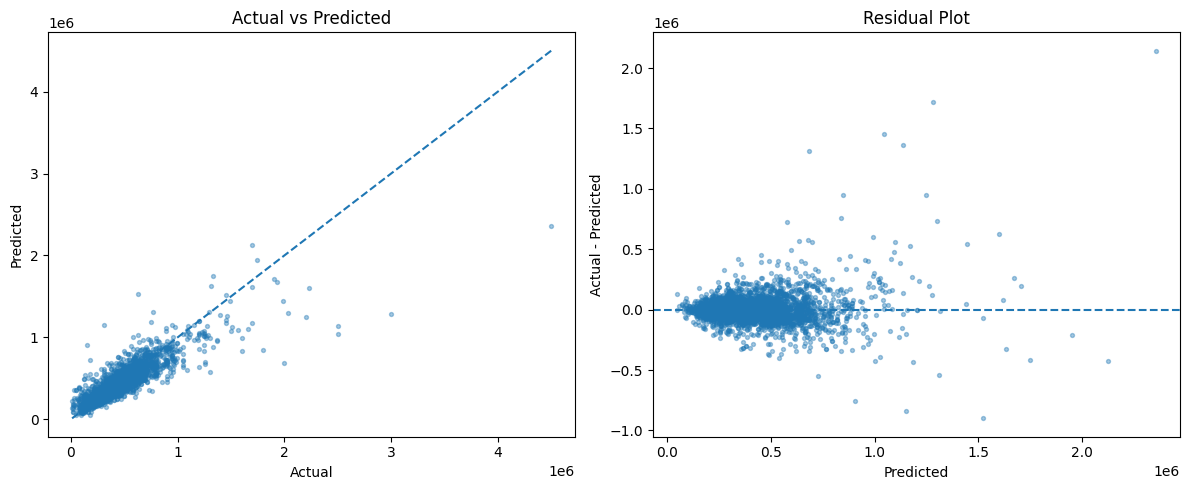

In [20]:
# 17. Actual vs Predicted + Residual của final 5-layer
final_name = "5-Layer MLP (0.001)" if final_dl_lr == 0.001 else "5-Layer MLP (0.01)"
final_pred = dl_predictions[final_name]
true_values = y_test.to_numpy()

N = min(5000, len(true_values))
rng = np.random.default_rng(SEED)
idx = rng.choice(len(true_values), size=N, replace=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].scatter(true_values[idx], final_pred[idx], s=8, alpha=0.4)
lo = min(true_values[idx].min(), final_pred[idx].min())
hi = max(true_values[idx].max(), final_pred[idx].max())
ax[0].plot([lo, hi], [lo, hi], "--")
ax[0].set_title("Actual vs Predicted")
ax[0].set_xlabel("Actual")
ax[0].set_ylabel("Predicted")

residuals = true_values - final_pred
ax[1].scatter(final_pred[idx], residuals[idx], s=8, alpha=0.4)
ax[1].axhline(0, linestyle="--")
ax[1].set_title("Residual Plot")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual - Predicted")

plt.tight_layout()
plt.show()

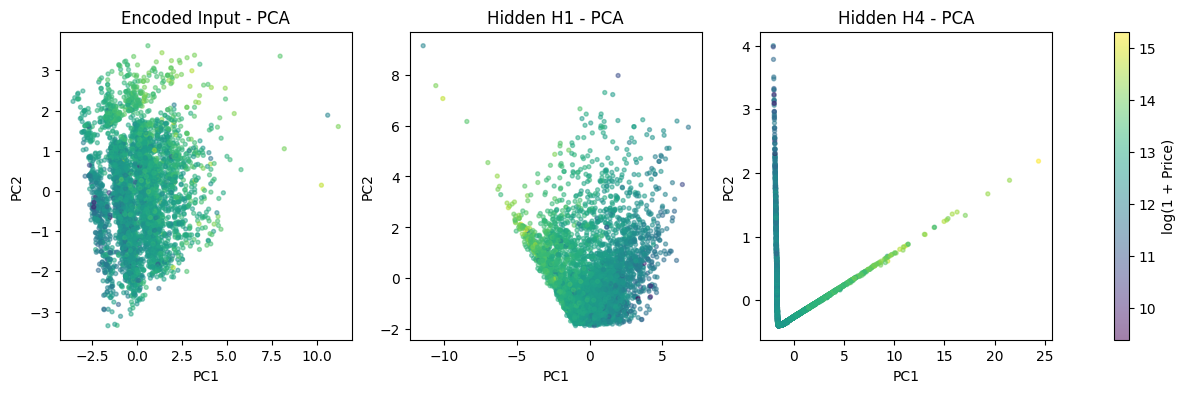

Encoded input: (7822, 633)
H1: (7822, 64)
H4: (7822, 8)


In [21]:
# 18. Learned Representation + PCA
final_dl_model.eval()

with torch.no_grad():
    h1, h2, h3, h4 = final_dl_model.extract_features(X_test_tensor.to(device))

h1_np = h1.cpu().numpy()
h4_np = h4.cpu().numpy()

N = min(5000, len(X_test_dense))
rng = np.random.default_rng(SEED)
idx = rng.choice(len(X_test_dense), size=N, replace=False)
price_color = np.log1p(y_test.to_numpy()[idx])

representations = [
    ("Encoded Input", X_test_dense[idx]),
    ("Hidden H1", h1_np[idx]),
    ("Hidden H4", h4_np[idx]),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, rep) in zip(axes, representations):
    pca_2d = PCA(n_components=2).fit_transform(rep)
    sc = ax.scatter(
        pca_2d[:, 0], pca_2d[:, 1],
        c=price_color, s=8, alpha=0.5
    )
    ax.set_title(f"{name} - PCA")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

fig.colorbar(sc, ax=axes.ravel().tolist(), label="log(1 + Price)")
plt.show()

print("Encoded input:", X_test_dense.shape)
print("H1:", h1_np.shape)
print("H4:", h4_np.shape)

In [22]:
# 19. Lưu mô hình
os.makedirs("models", exist_ok=True)

torch.save(final_dl_model.state_dict(), "models/house_deep_mlp_5layers.pth")
joblib.dump(preprocessor, "models/house_preprocessor.joblib")
joblib.dump(target_scaler, "models/house_target_scaler.joblib")

joblib.dump(
    {
        "input_dim": INPUT_DIM,
        "architecture": f"{INPUT_DIM}-64-32-16-8-1",
        "learning_rate": final_dl_lr,
        "target": TARGET,
        "numerical_features": NUM_FEATURES,
        "categorical_features": CAT_FEATURES
    },
    "models/house_model_info.joblib"
)

print("Selected 5-layer LR:", final_dl_lr)
print("Model saved:", os.path.exists("models/house_deep_mlp_5layers.pth"))

Selected 5-layer LR: 0.01
Model saved: True


## 20. Thảo luận kết quả

Sau khi chạy notebook, nhận xét:
- Model nào có RMSE thấp nhất?
- Random Forest và Deep Learning khác nhau thế nào?
- Deeper MLP có cải thiện so với Baseline không?
- Learning rate nào tốt hơn?
- Residual lớn tập trung ở vùng giá nào?
- Learned Representation thay đổi ra sao?

## 21. Kết luận

Notebook đã so sánh 3 mô hình Machine Learning với các Neural Network cho bài toán dự đoán giá nhà.

Deep Learning 5 Linear Layers:

**Encoded Input → 64 → 32 → 16 → 8 → 1**

Vì đây là Regression, đánh giá sử dụng **MAE, MSE, RMSE và R²**, không sử dụng Accuracy.